Loading The Packages

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing   import StandardScaler, OneHotEncoder
from sklearn.linear_model    import LinearRegression, LogisticRegression
from sklearn.tree            import DecisionTreeClassifier, plot_tree
from sklearn.ensemble        import RandomForestClassifier
from sklearn.pipeline        import Pipeline
from sklearn.compose         import ColumnTransformer
from sklearn.impute          import SimpleImputer
from sklearn.metrics         import mean_absolute_error, root_mean_squared_error, mean_squared_error, r2_score
from sklearn.metrics         import accuracy_score, precision_score, f1_score, recall_score, roc_auc_score, confusion_matrix
from imblearn.over_sampling  import SMOTE
import joblib

print("*-*-*-All Packages are imported Successfully-*-*-*")

*-*-*-All Packages are imported Successfully-*-*-*


Load And Read DataSet.

In [2]:
#  Load and Read the Exact Produced by EDA DataSet.
df = pd.read_csv("Eda_Titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Family_size
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,missing,Southampton,no,False,1
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False,1
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,missing,Southampton,yes,True,0
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False,1
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,missing,Southampton,no,True,0


Baseline Targeat Split

In [3]:
# Drop target and leak/redundant columns in x.
x = df.drop(columns=['alive', 'alone', 'class', 'survived', 'who'])
y = df['survived']

# Stratified Train and Test split 
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.02, stratify=y, random_state=42)
print(f"Target Distribution in Train:\n{y_train.value_counts(normalize=True)}")

Target Distribution in Train:
survived
0    0.617681
1    0.382319
Name: proportion, dtype: float64


In [4]:
df.tail()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone,Family_size
884,0,2,male,27.0,0,0,13.00,S,Second,man,True,missing,Southampton,no,True,0
885,1,1,female,19.0,0,0,30.00,S,First,woman,False,B,Southampton,yes,True,0
886,0,3,female,28.0,1,2,23.45,S,Third,woman,False,missing,Southampton,no,False,3
887,1,1,male,26.0,0,0,30.00,C,First,man,True,C,Cherbourg,yes,True,0
888,0,3,male,32.0,0,0,7.75,Q,Third,man,True,missing,Queenstown,no,True,0


Preprocessing (fit on training data only)

In [5]:
numeric_col = ['age', 'sibsp', 'parch', 'fare', 'pclass', 'Family_size']
categorical_col = ['sex', 'embarked']

# Now we do numeric Transformer and if there is any missing we can simpleimputer with (median) and Scaling.
numeric_transf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

categorical_transf = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy="most_frequent")),
    ('encoder', OneHotEncoder(handle_unknown='ignore'))
])

preprocessor = ColumnTransformer(transformers=[
    ('num', numeric_transf, numeric_col),
    ('cat', categorical_transf, categorical_col)
])
preprocessor

ColumnTransformer(transformers=[('num',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='median')),
                                                 ('scaler', StandardScaler())]),
                                 ['age', 'sibsp', 'parch', 'fare', 'pclass',
                                  'Family_size']),
                                ('cat',
                                 Pipeline(steps=[('imputer',
                                                  SimpleImputer(strategy='most_frequent')),
                                                 ('encoder',
                                                  OneHotEncoder(handle_unknown='ignore'))]),
                                 ['sex', 'embarked'])])

Train three classifiers on the same train/test split: Logistic Regression, Decision Tree, and Random Forest.

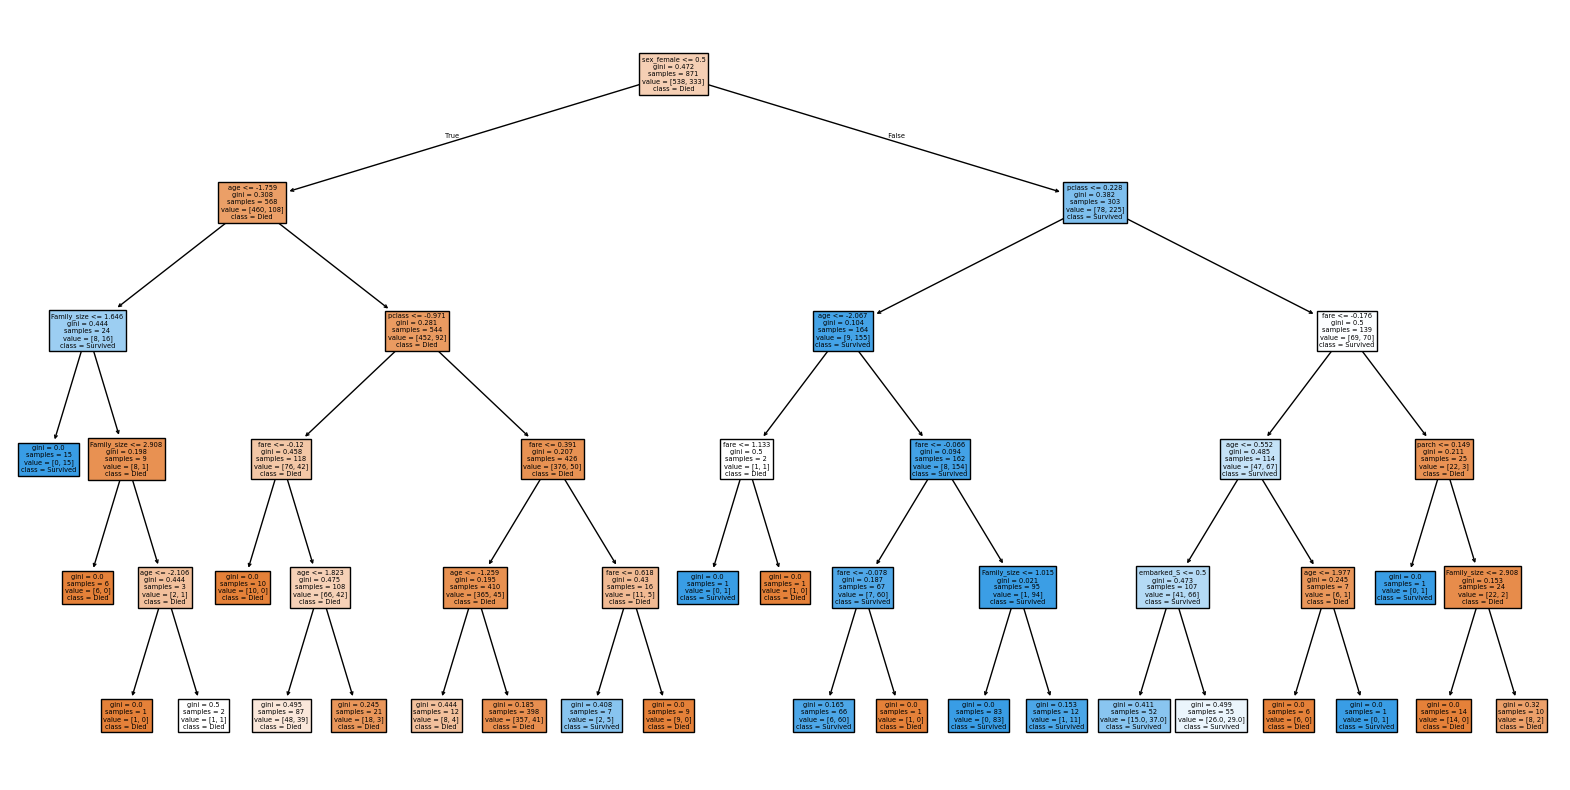


*-*-*-Classifier Evaluation-*-*-* 
                     Accuracy  Precision  Recall     F1    AUC
Logistic Regression     0.833      0.833   0.714  0.769  0.922
Decision Tree           0.889      0.857   0.857  0.857  0.974
Random Forest           0.833      0.750   0.857  0.800  0.935


In [6]:
model ={
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=100),
    "Decision Tree"      : DecisionTreeClassifier(max_depth=5, random_state=42),
    "Random Forest"      : RandomForestClassifier(n_estimators=100, random_state=42)
    }

results = {}

for name, model in model.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor), ('classifier', model)])
    clf.fit(x_train, y_train)
    y_pred = clf.predict(x_test)
    y_prob = clf.predict_proba(x_test)[:, 1]
    
    results[name] = {
        "Accuracy" : accuracy_score(y_test, y_pred),
        "Precision": precision_score(y_test, y_pred),
        "Recall"   : recall_score(y_test, y_pred),
        "F1"       : f1_score(y_test, y_pred),
        "AUC"      : roc_auc_score(y_test, y_prob)
    }
    
    if name == "Decision Tree":
        plt.figure(figsize=(20,10))
        feature_names = numeric_col + list(clf.named_steps['preprocessor'].named_transformers_['cat'].named_steps['encoder'].get_feature_names_out(categorical_col))
        plot_tree(clf.named_steps['classifier'], feature_names=feature_names, class_names=['Died', 'Survived'], filled=True)
        plt.savefig("Decision_tree.png")
        plt.show()
        plt.close()
        
print("\n*-*-*-Classifier Evaluation-*-*-* ")
metrics_df = pd.DataFrame(results).T
print(metrics_df.round(3))

Imbalance handling comparison

In [7]:
print("*-*-*-Imbalance handling comparison-*-*-*")

# Preprocess Train and Test arrays Specifically to apply SMOTE correctly

x_train_trans = preprocessor.fit_transform(x_train)
x_test_trans  = preprocessor.transform(x_test)

# SMOTE oversampling applied only to the training fold.add()
smote = SMOTE(random_state=42)
x_train_smote, y_train_smote = smote.fit_resample(x_train_trans, y_train)

# Compara Variants
# Logistic Regression (Baseline--Model)
lr_base = LogisticRegression(random_state=42)
lr_base.fit(x_train_trans, y_train)

#  Logistic Regression (Balanced--Model)
lr_bal = LogisticRegression(class_weight='balanced', random_state=42)
lr_bal.fit(x_train_trans, y_train)

#  Logistic Regression (SMOTE--Model)
lr_smote = LogisticRegression(random_state=42)
lr_smote.fit(x_train_trans, y_train)

variants = {'Baseline': lr_base, 'Balanced': lr_bal, 'Smote': lr_smote}
for v_name, v_model in variants.items():
    v_pred = v_model.predict(x_test_trans)
    print(f"{v_name} --F1: {f1_score(y_test, v_pred):.3f} | Recall: {recall_score(y_test, v_pred):.3f}")

*-*-*-Imbalance handling comparison-*-*-*
Baseline --F1: 0.769 | Recall: 0.714
Balanced --F1: 0.750 | Recall: 0.857
Smote --F1: 0.769 | Recall: 0.714


Hyperparameter tuning  GridSearchCV over the Random Forest's

In [8]:
print("*-*-*-Hyperparameter tuning GridSearchCV over the Random Forest's-*-*-*")
rf_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('model', RandomForestClassifier(oob_score=True, random_state=42))
])

param_grid ={
    "model__n_estimators":[50, 100, 150, 200],
    "model__max_depth" : [5, 10, 15, None],
    "model__max_features":['sqrt', 'log2']
}

grid_search = GridSearchCV(rf_pipe, param_grid, cv=5, scoring='accuracy')
grid_search.fit(x_train, y_train)
best_rf = grid_search.best_estimator_
oob_score = best_rf.named_steps['model'].oob_score_
print(f"Best Params: {grid_search.best_params_}")
print(f"Best OOB Score: {oob_score:.3f}")


*-*-*-Hyperparameter tuning GridSearchCV over the Random Forest's-*-*-*
Best Params: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__n_estimators': 50}
Best OOB Score: 0.828


Regression side-task  (predict [Fate])

*-*-*-Regression Side Task Predict [Fare]-*-*-*
MAE: 21.139 | RMSE: 41.747 | R2 : 0.347 | Adj_r2 : 0.308


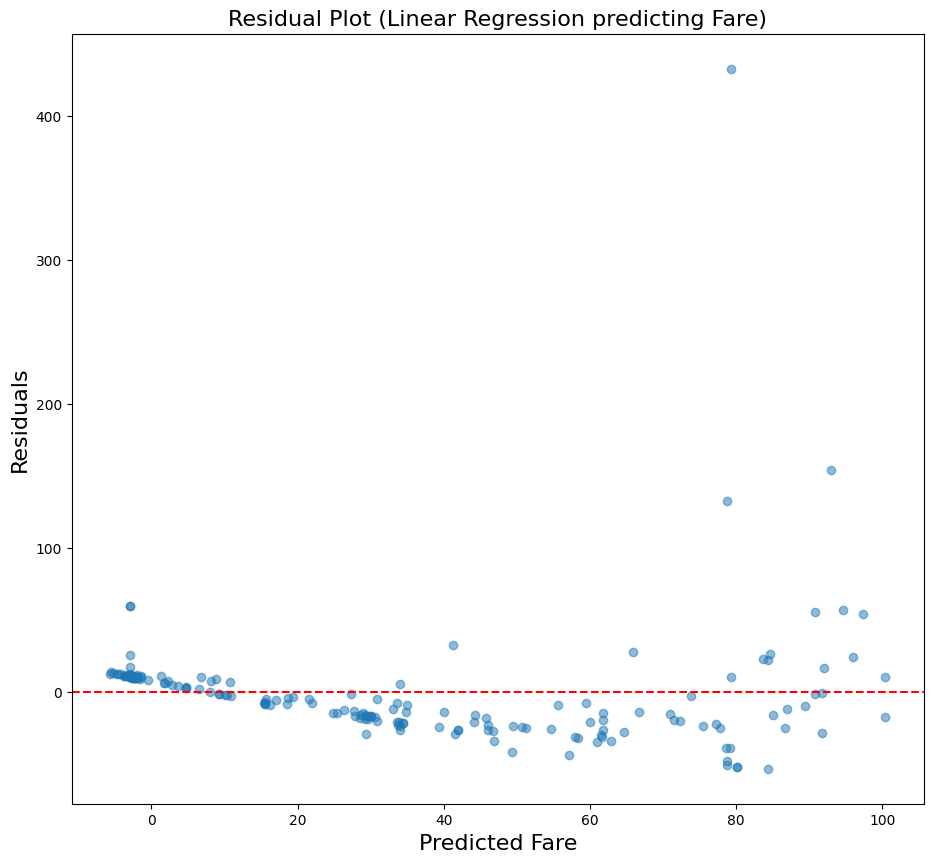

In [24]:
print("*-*-*-Regression Side Task Predict [Fare]-*-*-*")
df_regr = df.dropna(subset=['fare'])
x_regr = df_regr.drop(columns=['fare', 'alive', 'adult_male', 'alone', 'who', 'Family_size'])
y_regr = df_regr['fare']

x_train_reg, x_test_reg, y_train_reg, y_test_reg = train_test_split(x_regr, y_regr, test_size=0.2, random_state=42)

# Build a preprocessor adapted to the regression features (avoid requesting columns that were dropped)
numeric_col_reg = [c for c in numeric_col if c in x_regr.columns]
categorical_col_reg = [c for c in categorical_col if c in x_regr.columns]

preprocessor_reg = ColumnTransformer(transformers=[
    ('num', numeric_transf, numeric_col_reg),
    ('cat', categorical_transf, categorical_col_reg)
])

reg_pipeline = Pipeline(steps=[
    ('preprocessor', preprocessor_reg),
    ('regression', LinearRegression())
])

reg_pipeline.fit(x_train_reg, y_train_reg)
y_pred_reg = reg_pipeline.predict(x_test_reg)

MAE = mean_absolute_error(y_test_reg, y_pred_reg)
RMSE = root_mean_squared_error(y_test_reg, y_pred_reg)
R2  = r2_score(y_test_reg, y_pred_reg)
n  = len(x_test_reg)
p = x_train_reg.shape[1]
adj_r2 = 1 - (1-R2) * ((n-1)/(n - p - 1))

print(f"MAE: {MAE:.3f} | RMSE: {RMSE:.3f} | R2 : {R2:.3f} | Adj_r2 : {adj_r2:.3f}")
# Residual plot to check for heteroscedasticity
residuals = y_test_reg - y_pred_reg
plt.figure(figsize=(11,10))
plt.scatter(y_pred_reg, residuals, alpha=0.5)
plt.axhline(0, color='r', linestyle='--')
plt.title("Residual Plot (Linear Regression predicting Fare)", fontsize=16)
plt.xlabel("Predicted Fare", fontsize=16)
plt.ylabel("Residuals", fontsize=16)
plt.savefig("regression_residuals.png")
plt.show()
plt.close()

Write a model comparison table that presents the three classifiers' metrics (accuracy, precision, recall, F1, AUC) side by side, and the regression model's metrics (MAE, RMSE, R², Adjusted R²) side by side as their own separate columns. Classification metrics and regression metrics are on different scales and are not directly comparable numbers — the table must present them as two distinct metric groups (one per model type), not implied to be on a single shared scale. Add a 3–5 sentence final written recommendation of which classifier you would deploy and why, referencing specific metric values.

In [43]:
print("\n*-*-*-Classifier Evaluation-*-*-* ")
metrics_df = pd.DataFrame(results).T
print(metrics_df.round(3))
print("-"*63)
print("\n*-*-*-Regression Metrics-*-*-*")
print("Regression Model\t MAE   |   RMSE  |     R2  |   Adj_R2")
print(f"\nMultivariate Linear\t{MAE:.3f} |  {RMSE:.3f} |  {R2:.3f}  |  {adj_r2:.3f}")
print("-"*63)


*-*-*-Classifier Evaluation-*-*-* 
                     Accuracy  Precision  Recall     F1    AUC
Logistic Regression     0.833      0.833   0.714  0.769  0.922
Decision Tree           0.889      0.857   0.857  0.857  0.974
Random Forest           0.833      0.750   0.857  0.800  0.935
---------------------------------------------------------------

*-*-*-Regression Metrics-*-*-*
Regression Model	 MAE   |   RMSE  |     R2  |   Adj_R2

Multivariate Linear	21.139 |  41.747 |  0.347  |  0.308
---------------------------------------------------------------


Finally I recommend to deploying the Decision tree model for production. it achieves the highest overall Accuracy(0.889) and an exceptional AUC(0.974), demonstrating superior overall discriminative power compared to Random Forest (0.935 AUC) and Logistic Regression (0.922 AUC). Furthermore it attains the top performing F1 score(0.857) by maintaining a perfect balance between precision(0.857) and recall(0.857), significantly outperforming Logistic Regression in recall(0.714) and Random Forest in precision (0.750). This well rounded metric profile guarantees high prediction accuracy without sacrificing sensitivity to positive cases or introducing excessive false positives.

Now Export End--to--End Pipeline save

In [47]:
print("*-*-*-Saving And Reloading Pipeline-*-*-*")
joblib.dump(best_rf, 'best_rf_pipeline.pkl')
print("*-*-*-Pipeline saved to 'Best_rf_pipeline.pkl'. in our folder file-*-*-*")

*-*-*-Saving And Reloading Pipeline-*-*-*
*-*-*-Pipeline saved to 'Best_rf_pipeline.pkl'. in our folder file-*-*-*


Again Re-Load the Pipeline file for test.

In [57]:
# Reloading the Sample Data.
loaded_pipe = joblib.load('best_rf_pipeline.pkl')
sample_raw = x_test.iloc[0]
prediction = loaded_pipe.predict(x_test)
print(f"Prediction from the sample Data:\n {prediction}")
print("\n*-*-*-Module 2 Execution Completed-*-*-*")

Prediction from the sample Data:
 [1 1 0 0 0 0 0 0 0 0 0 1 1 1 1 1 1 1]

*-*-*-Module 2 Execution Completed-*-*-*
